![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [31]:
# !sudo apt-get install libgomp1
# !sudo apt-get install libxft2
# !sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [32]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [33]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [34]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

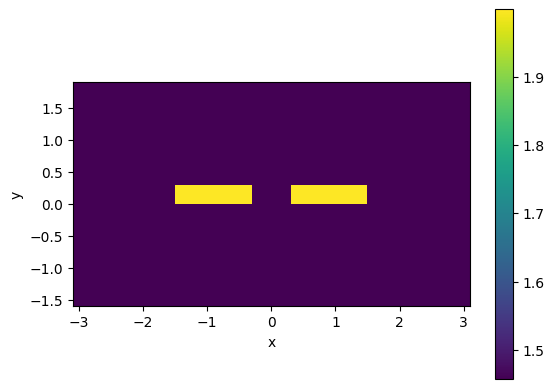

In [35]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=30 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [36]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-04-30 14:36:26.562 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_34835ab47ea23281.npz.
[1.61793773+9.80777918e-05j 1.61017908+9.35979812e-05j
 1.53709743+1.75770034e-04j 1.52225525+1.75486218e-04j]


In [37]:
dcoupler_cs.fraction_te

array([0.99553025, 0.99595819, 0.00824261, 0.01038074])

In [38]:
dcoupler_cs.fraction_tm

array([0.00446975, 0.00404181, 0.99175739, 0.98961926])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

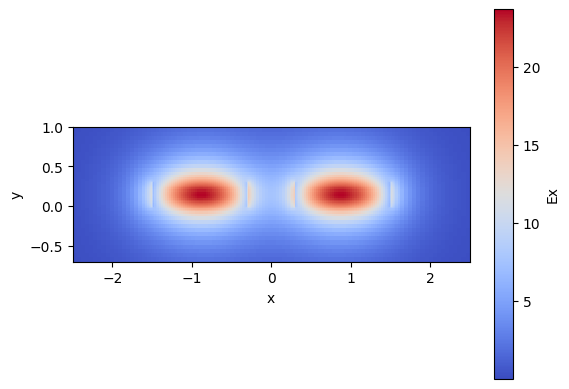

In [39]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

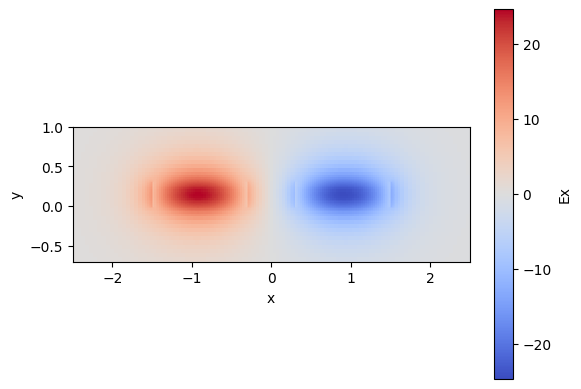

In [40]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

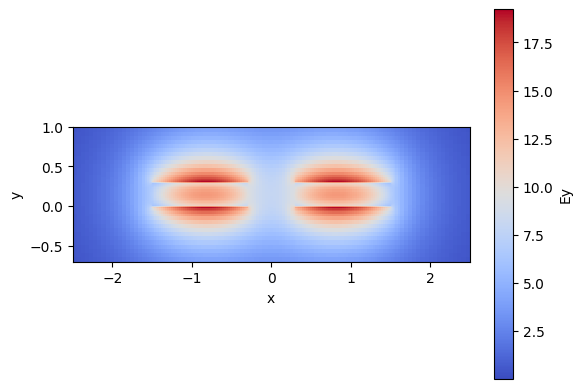

In [41]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

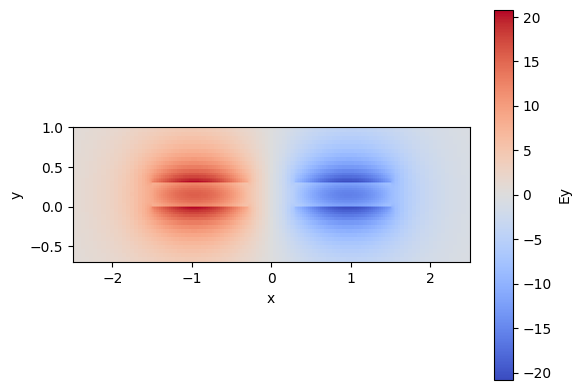

In [42]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [43]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

99.88859193722972
52.21605465376124


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [44]:
dcoupler_cs.coupling_length()

array([99.88859194, 52.21605465])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">
<img src="k.png" alt="Coupling Coefficient Equation" width="400" style="filter: invert();">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

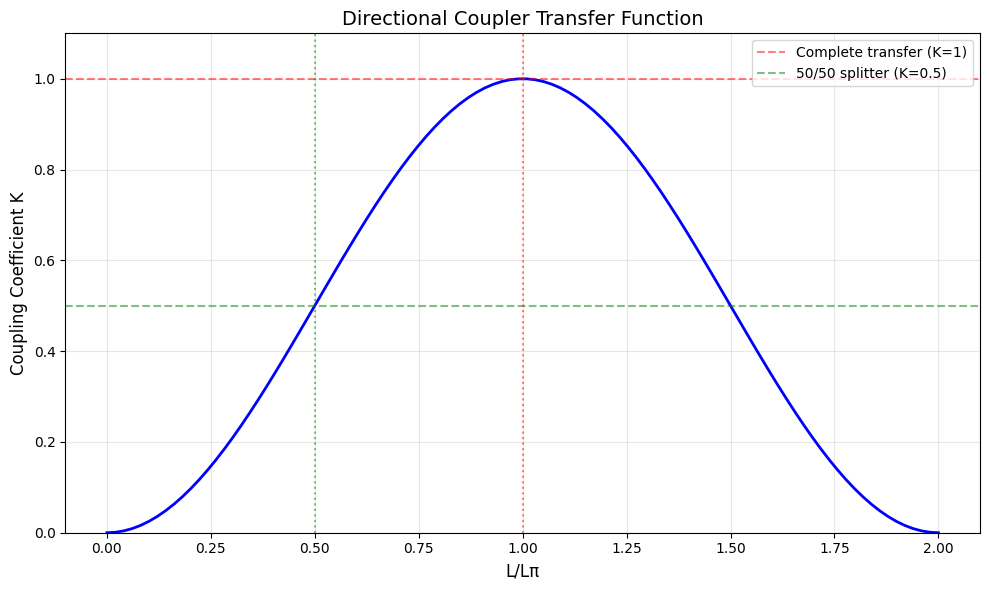

Resultados importantes:
- Transferencia completa (K=1): L = Lπ = 99.89 µm
- Splitter 50/50 (K=0.5): L = Lπ/2 = 49.94 µm
- Sin acoplamiento (K=0): L = 0, 2Lπ, 4Lπ...


In [45]:
# LO.2 - Plot K vs L/Lπ
import numpy as np
import matplotlib.pyplot as plt

# Define range of L/Lπ values
L_ratio = np.linspace(0, 2, 100)

# Calculate coupling coefficient K = sin²(πL/2Lπ)
K = np.sin(np.pi * L_ratio / 2)**2

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(L_ratio, K, 'b-', linewidth=2)
plt.xlabel('L/Lπ', fontsize=12)
plt.ylabel('Coupling Coefficient K', fontsize=12)
plt.title('Directional Coupler Transfer Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Complete transfer (K=1)')
plt.axhline(y=0.5, color='g', linestyle='--', alpha=0.5, label='50/50 splitter (K=0.5)')
plt.axvline(x=1.0, color='r', linestyle=':', alpha=0.5)
plt.axvline(x=0.5, color='g', linestyle=':', alpha=0.5)
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("Resultados importantes:")
print(f"- Transferencia completa (K=1): L = Lπ = {L_pi_TE:.2f} µm")
print(f"- Splitter 50/50 (K=0.5): L = Lπ/2 = {L_pi_TE/2:.2f} µm")
print(f"- Sin acoplamiento (K=0): L = 0, 2Lπ, 4Lπ...")

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [46]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605179156  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


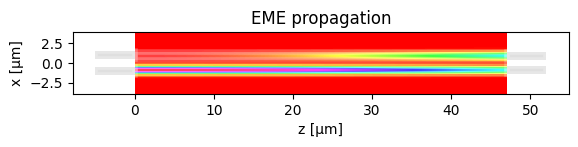

In [47]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

Simulating gap = 0.2 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9071
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7802
Total OUT power: 0.7586
Excess loss [dB] =  1.2000
------------------------
Power over OUTs:  ['0.3792', '0.3794']
Ratio over OUTs ['0.4999', '0.5001']
L_pi = 25.8142 um
L_50:50 = 12.9071 um
Power OUT = [0.37919436 0.37938446]
Ratio OUT = [0.4998747 0.5001253]
Excess loss = 1.2000 dB
--------------------------------------------------
Simulating gap = 0.4 um


...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']
L_pi = 173.9639 um
L_50:50 = 86.9819 um
Power OUT = [0.488796  0.4889835]
Ratio OUT = [0.49990412 0.50009588]
Excess loss = 0.0976 dB
--------------------------------------------------
Simulating gap = 1.0 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


ValueError: Number of samples, -3189, must be non-negative.

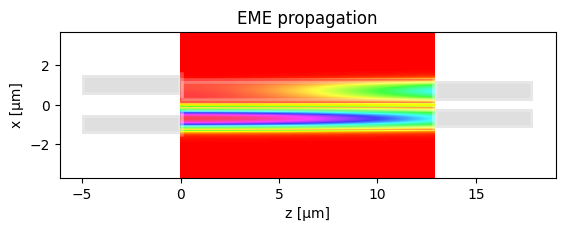

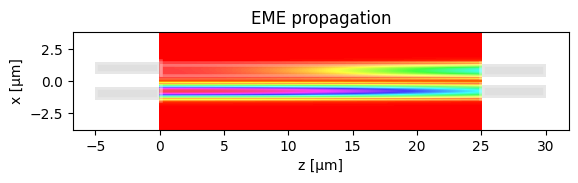

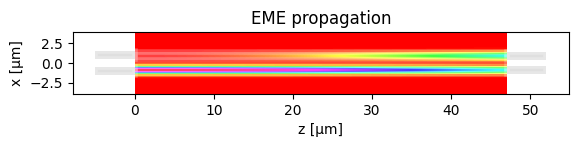

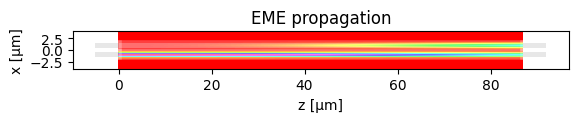

In [48]:
# LO.3 - Sweep gaps between 0.2 and 1.2 um

gaps_to_sweep = np.arange(0.2, 1.4, 0.2)

results_gap_sweep = []

for gap in gaps_to_sweep:
    print(f"Simulating gap = {gap:.1f} um")

    m_sweep = DC_EME()
    m_sweep.MMI_num_modes = 12
    m_sweep.DC_wg_gap = gap
    m_sweep.DC_wg_width = 1.2
    m_sweep.DC_N_waveguides = 2

    # Calculate modes
    m_sweep.find_all_modes()

    # Calculate L_pi
    L_pi_sweep = m_sweep.get_L_pi()
    L_5050_sweep = 0.5 * L_pi_sweep

    # Configure 2x2 50/50 coupler
    m_sweep.n_IN = 2
    m_sweep.n_OUT = 2
    m_sweep.L_MMI = L_5050_sweep

    # Propagation
    m_sweep.propagation()

    results_gap_sweep.append({
        "gap": gap,
        "L_pi": L_pi_sweep,
        "L_5050": L_5050_sweep,
        "power_OUT": m_sweep.power_OUT,
        "ratio_OUT": m_sweep.ratio_OUT,
        "excess_loss_dB": m_sweep.EL
    })

    print(f"L_pi = {L_pi_sweep:.4f} um")
    print(f"L_50:50 = {L_5050_sweep:.4f} um")
    print(f"Power OUT = {m_sweep.power_OUT}")
    print(f"Ratio OUT = {m_sweep.ratio_OUT}")
    print(f"Excess loss = {m_sweep.EL:.4f} dB")
    print("-" * 50)

# Plot L_pi vs gap
gaps = [r["gap"] for r in results_gap_sweep]
L_pis = [r["L_pi"] for r in results_gap_sweep]

plt.figure(figsize=(10, 6))
plt.plot(gaps, L_pis, "bo-", linewidth=2, markersize=8)
plt.xlabel("Gap (um)")
plt.ylabel("Lpi (um)")
plt.title("Lpi vs gap for 2x2 directional coupler")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# LO.3 - 2x2 Directional Coupler
# Caso individual para sacar la propagación del gap que quieras estudiar

wg_width = 1.2
gap_selected = 0.6   # cámbialo luego a 0.2, 0.4, 0.6, 0.8, 1.0, 1.2

wg_N = 2

m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = gap_selected
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N

# 1) Calcular modos del directional coupler
m.find_all_modes()

# 2) Obtener L_pi y longitud 50:50
L_pi = m.get_L_pi()
L_5050 = 0.5 * L_pi

print(f"Gap = {gap_selected:.1f} um")
print(f"L_pi = {L_pi:.4f} um")
print(f"L_50:50 = L_pi/2 = {L_5050:.4f} um")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap = 0.6 um
L_pi = 94.0274 um
L_50:50 = L_pi/2 = 47.0137 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


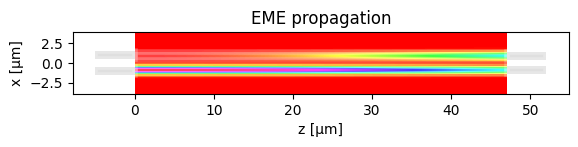

In [ ]:
# Configuración 2x2 y propagación para el gap elegido arriba

m.n_IN = 2
m.n_OUT = 2

# Para un 3 dB coupler / 50:50
m.L_MMI = L_5050

# Ejecutar propagación y mostrar resultados
m.propagation()

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



HINT. Calculate manually the L_pi you may need to achieve K=0.01
Then you can sweep the gap and calculate the L_pi until reaching 
the desired value.

Condición para guías desacopladas:
K objetivo = 0.01
L = 10.0 mm
Lpi mínimo requerido = 156.82 mm
Delta neff máximo permitido = 4.942e-06

--- Deep waveguide ---
2026-04-30 12:13:13.813 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c735717a8742a223.npz.
gap = 0.20 um | Lpi = 0.0180 mm | K = 1.0000
2026-04-30 12:13:13.835 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f0903b36a6669153.npz.


gap = 0.40 um | Lpi = 0.0328 mm | K = 1.0000
2026-04-30 12:13:13.849 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_40b89b65a6f22400.npz.
gap = 0.60 um | Lpi = 0.0595 mm | K = 1.0000
2026-04-30 12:13:13.860 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_16be99bd3e78a9eb.npz.
gap = 0.80 um | Lpi = 0.1047 mm | K = 1.0000
2026-04-30 12:13:13.869 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_81cd52b7728ca66a.npz.
gap = 1.00 um | Lpi = 0.1844 mm | K = 1.0000
2026-04-30 12:13:13.879 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_591cb4dce0a44c14.npz.
gap = 1.20 um | Lpi = 0.2909 mm | K = 1.0000
2026-04-30 12:13:13.891 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a101b17ecf958c16.npz.
gap = 1.50 um | Lpi = 0.4865 mm | K = 1.0000
2026-04-30 12:13:13.902 | INFO     | gplugins.tidy3d.modes:_data:266 -

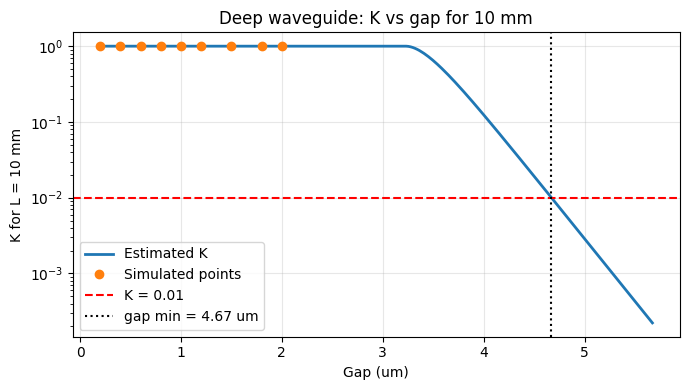


Resultado Deep:
gap mínimo estimado = 4.67 um
Lpi requerido = 156.82 mm
K objetivo = 0.01

--- Shallow waveguide ---
2026-04-30 12:13:14.221 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b562e744298eb15d.npz.
gap = 0.20 um | Lpi = 0.0185 mm | K = 1.0000
2026-04-30 12:13:14.224 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7035fcd667db234e.npz.
gap = 0.40 um | Lpi = 0.0271 mm | K = 1.0000
2026-04-30 12:13:14.228 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d91696d09038bbb2.npz.
gap = 0.60 um | Lpi = 0.0397 mm | K = 1.0000
2026-04-30 12:13:14.233 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_abf251362ccac02d.npz.
gap = 0.80 um | Lpi = 0.0580 mm | K = 1.0000
2026-04-30 12:13:14.239 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f737b1eb28a10412.npz.
gap = 1.00 um | Lpi = 0.0843 mm | K = 1.00

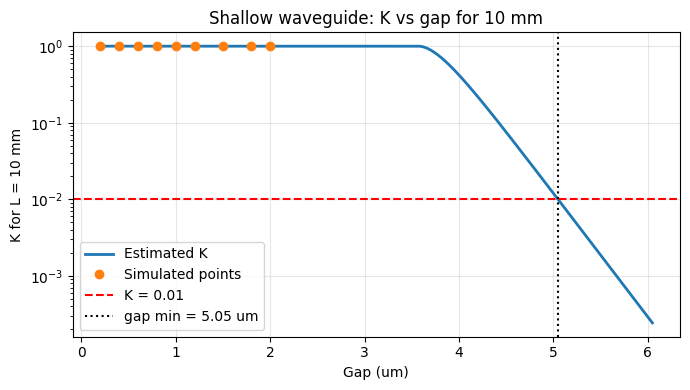


Resultado Shallow:
gap mínimo estimado = 5.05 um
Lpi requerido = 156.82 mm
K objetivo = 0.01

Resumen final LO.4:
Deep waveguide: gap mínimo estimado = 4.67 um
Shallow waveguide: gap mínimo estimado = 5.05 um


In [ ]:
# LO.4 - Parallel uncoupled waveguides - TE0 mode

try:
    nm
except NameError:
    nm = 1e-3

# Parámetros del enunciado
lambda_lo4 = 1.55      # um
wg_width_lo4 = 1.0     # um
core_h_lo4 = 300 * nm  # 300 nm = 0.3 um

L_parallel = 10_000    # um = 10 mm
K_target = 0.01

slab_deep = 0 * nm
slab_shallow = 150 * nm

# Cálculo manual del Lpi necesario para tener K = 0.01
# K = sin^2((pi/2)*(L/Lpi))
L_over_Lpi_limit = (2 / np.pi) * np.arcsin(np.sqrt(K_target))
Lpi_required = L_parallel / L_over_Lpi_limit
dneff_required = lambda_lo4 / (2 * Lpi_required)

print("Condición para guías desacopladas:")
print(f"K objetivo = {K_target}")
print(f"L = {L_parallel/1000:.1f} mm")
print(f"Lpi mínimo requerido = {Lpi_required/1000:.2f} mm")
print(f"Delta neff máximo permitido = {dneff_required:.3e}")


def get_te0_lpi(gap_um, slab_thickness_um, grid_resolution=12):
    """
    Calcula Lpi usando los dos modos TE principales del acoplador.
    """
    dc = gt.modes.WaveguideCoupler(
        core_width=(wg_width_lo4, wg_width_lo4),
        slab_thickness=slab_thickness_um,
        core_thickness=core_h_lo4,
        gap=gap_um,
        core_material="sin",
        clad_material="sio2",
        wavelength=lambda_lo4,
        num_modes=4,
        cache_path=".cache/",
        precision="double",
        max_grid_scaling=1.5,
        grid_resolution=grid_resolution,
    )

    neff = np.array(dc.n_eff).real
    frac_te = np.array(dc.fraction_te)

    # Elegimos los dos modos más TE
    te_idx = np.where(frac_te > 0.5)[0]

    if len(te_idx) < 2:
        te_idx = np.argsort(frac_te)[-2:]

    # Ordenamos por neff para coger los dos supermodos TE principales
    te_idx = te_idx[np.argsort(neff[te_idx])[::-1]]
    i0, i1 = te_idx[:2]

    delta_neff = abs(neff[i0] - neff[i1])
    Lpi = lambda_lo4 / (2 * delta_neff)

    return Lpi, delta_neff, neff[i0], neff[i1]


def K_from_Lpi_conservative(Lpi):
    """
    K para L = 10 mm.
    Usamos una estimación conservadora para evitar mínimos accidentales
    por periodicidad cuando las guías todavía están muy acopladas.
    """
    phase = (np.pi / 2) * (L_parallel / Lpi)

    if phase >= np.pi / 2:
        return 1.0
    else:
        return np.sin(phase) ** 2


def analyze_waveguide_type(slab_thickness_um, label):
    """
    Barrido + ajuste exponencial para estimar el gap mínimo.
    El acoplo evanescente decrece aproximadamente de forma exponencial con el gap.
    """
    print(f"\n--- {label} waveguide ---")

    # Barrido moderado: evita ir a gaps demasiado grandes donde el solver puede volverse inestable
    gap_sim = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0])

    results = []

    for gap in gap_sim:
        try:
            Lpi, dneff, neff0, neff1 = get_te0_lpi(gap, slab_thickness_um)

            K_value = K_from_Lpi_conservative(Lpi)

            results.append({
                "gap": gap,
                "Lpi": Lpi,
                "dneff": dneff,
                "K": K_value,
                "neff0": neff0,
                "neff1": neff1,
            })

            print(
                f"gap = {gap:.2f} um | "
                f"Lpi = {Lpi/1000:.4f} mm | "
                f"K = {K_value:.4f}"
            )

        except Exception as e:
            print(f"gap = {gap:.2f} um failed: {e}")

    gaps = np.array([r["gap"] for r in results])
    dneffs = np.array([r["dneff"] for r in results])
    Lpis = np.array([r["Lpi"] for r in results])
    Ks = np.array([r["K"] for r in results])

    # Ajuste exponencial: delta_neff = A * exp(B * gap)
    # Filtramos puntos no físicos donde Lpi no aumenta al aumentar el gap
    valid = np.isfinite(dneffs) & (dneffs > 0) & np.isfinite(Lpis)

    cummax_Lpi = np.maximum.accumulate(Lpis)
    monotonic = Lpis >= np.r_[-np.inf, cummax_Lpi[:-1]]

    fit_mask = valid & monotonic

    fit_gaps = gaps[fit_mask]
    fit_dneffs = dneffs[fit_mask]

    # Si hay muchos puntos, quitamos el primero para ajustar mejor la zona evanescente
    if len(fit_gaps) > 5:
        fit_gaps = fit_gaps[1:]
        fit_dneffs = fit_dneffs[1:]

    B, logA = np.polyfit(fit_gaps, np.log(fit_dneffs), 1)
    A = np.exp(logA)

    # Gap mínimo estimado para cumplir delta_neff < delta_neff_required
    gap_min = (np.log(dneff_required) - logA) / B

    # Curva extrapolada para pintar K vs gap
    gap_curve = np.linspace(0.2, max(gap_min + 1.0, 3.0), 250)
    dneff_curve = A * np.exp(B * gap_curve)
    Lpi_curve = lambda_lo4 / (2 * dneff_curve)
    K_curve = np.array([K_from_Lpi_conservative(Lpi) for Lpi in Lpi_curve])

    # Gráfica para el PPT
    plt.figure(figsize=(7, 4))
    plt.plot(gap_curve, K_curve, "-", linewidth=2, label="Estimated K")
    plt.plot(gaps, Ks, "o", label="Simulated points")
    plt.axhline(K_target, linestyle="--", color="red", label="K = 0.01")
    plt.axvline(gap_min, linestyle=":", color="black", label=f"gap min = {gap_min:.2f} um")

    plt.xlabel("Gap (um)")
    plt.ylabel("K for L = 10 mm")
    plt.title(f"{label} waveguide: K vs gap for 10 mm")
    plt.grid(True, alpha=0.3)
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nResultado {label}:")
    print(f"gap mínimo estimado = {gap_min:.2f} um")
    print(f"Lpi requerido = {Lpi_required/1000:.2f} mm")
    print(f"K objetivo = {K_target}")

    return {
        "label": label,
        "gap_min": gap_min,
        "A": A,
        "B": B,
        "results": results,
    }


deep_result = analyze_waveguide_type(slab_deep, "Deep")
shallow_result = analyze_waveguide_type(slab_shallow, "Shallow")

print("\nResumen final LO.4:")
print(f"Deep waveguide: gap mínimo estimado = {deep_result['gap_min']:.2f} um")
print(f"Shallow waveguide: gap mínimo estimado = {shallow_result['gap_min']:.2f} um")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [ ]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-04-30 12:13:14.524 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [ ]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

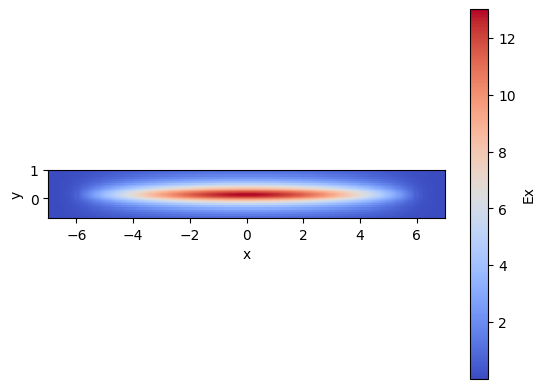

In [ ]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

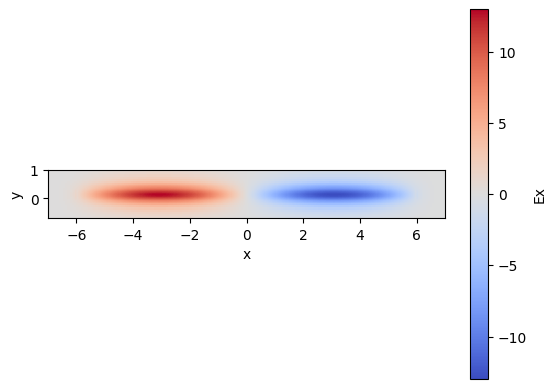

In [ ]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

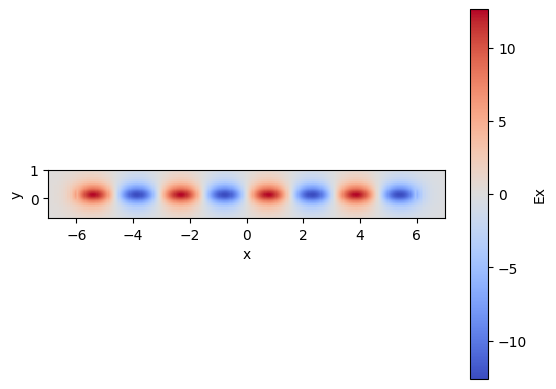

In [ ]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [ ]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


In [ ]:
# LO.5 - Summary for the report (AÑADIDO)

neff = mmi_body_waveguide.n_eff
fraction_te = mmi_body_waveguide.fraction_te

print("MMI body width =", mmi_body_w, "um")
print("Wavelength =", lambda_c, "um")
print("Deep-etched waveguide, thickness = 300 nm")
print()

print("First calculated modes:")
for i in range(10):
    pol = "TE-like" if fraction_te[i] > 0.5 else "TM-like"
    print(
        f"mode {i}: "
        f"neff = {neff[i].real:.6f}, "
        f"fraction_TE = {fraction_te[i]:.4f}, "
        f"{pol}"
    )

print()
print("Lpi calculation:")
print(f"neff mode 0 = {neff[0].real:.6f}")
print(f"neff mode 1 = {neff[1].real:.6f}")
print(f"Delta neff = {d_n_eff:.6f}")
print(f"Lpi = {L_pi:.4f} um")

MMI body width = 12 um
Wavelength = 1.55 um
Deep-etched waveguide, thickness = 300 nm

First calculated modes:
mode 0: neff = 1.678660, fraction_TE = 1.0000, TE-like
mode 1: neff = 1.675127, fraction_TE = 1.0000, TE-like
mode 2: neff = 1.669228, fraction_TE = 0.9999, TE-like
mode 3: neff = 1.660945, fraction_TE = 0.9999, TE-like
mode 4: neff = 1.650253, fraction_TE = 0.9998, TE-like
mode 5: neff = 1.637121, fraction_TE = 0.9997, TE-like
mode 6: neff = 1.621513, fraction_TE = 0.9995, TE-like
mode 7: neff = 1.603391, fraction_TE = 0.9993, TE-like
mode 8: neff = 1.582715, fraction_TE = 0.9990, TE-like
mode 9: neff = 1.577421, fraction_TE = 0.0002, TM-like

Lpi calculation:
neff mode 0 = 1.678660
neff mode 1 = 1.675127
Delta neff = 0.003532
Lpi = 219.4112 um


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256005  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


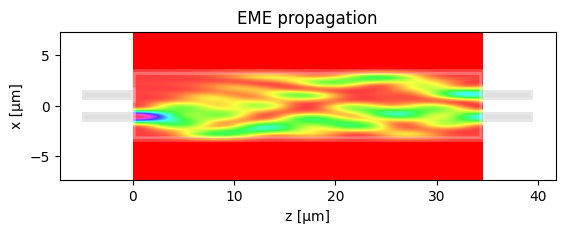

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


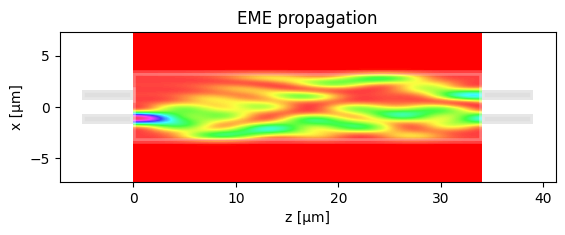

: 

In [ ]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [58]:
# Design flow for MMI

mmi_Width = 6.6


m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.7 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255732  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/678 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.6000
IO wg width 1.0000
IO wg width increment 0.7000
------------------------
Total power IN coupled 0.9919
Total OUT power: 0.9824
Excess loss [dB] =  0.0773
------------------------
Power over OUTs:  ['0.5013', '0.4811']
Ratio over OUTs ['0.5103', '0.4897']


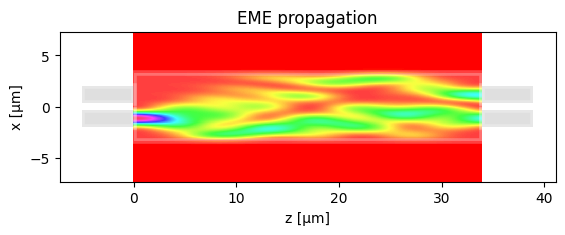

In [59]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.065
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.60 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [68]:
# LO.7 - 1x4 Multimode Interference Coupler

mmi_Width = 12.0

m = MMI_EME()
m.MMI_width = mmi_Width
m.MMI_num_modes = 30
m.wg_width_dw = 0.6

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544106842  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/812 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9919
Total OUT power: 0.9529
Excess loss [dB] =  0.2097
------------------------
Power over OUTs:  ['0.2347', '0.2418', '0.2418', '0.2346']
Ratio over OUTs ['0.2463', '0.2537', '0.2538', '0.2462']


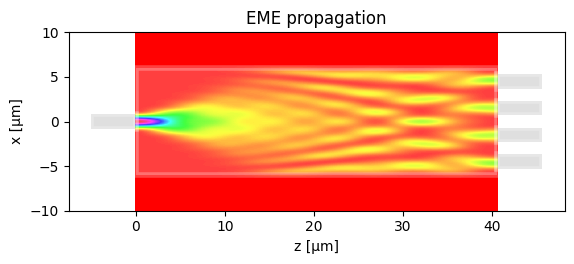

In [69]:
# Configure 1x4 MMI

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = np.array([0.0])

m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

m.L_MMI = (3/4) * L_pi / m.n_OUT
m.dL_MMI = -0.5

m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points